<a href="https://colab.research.google.com/github/epythonlab2/AI_4_health/blob/main/module_2_model_deployment_interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<header style="font-family: 'Inter', sans-serif; background: #ffffff; padding: 16px; border-radius: 8px; border: 1px solid #e1e4e8; display: flex; align-items: center; gap: 12px; box-shadow: 0 2px 8px rgba(0,0,0,0.05); margin-bottom: 10px;">
    <div style="width: 4px; height: 35px; background: linear-gradient(to bottom, #4e73df, #1cc88a); border-radius: 2px;"></div>
    <h1 style="color: #1a1a1a; margin: 0; font-size: 20px; font-weight: 700; border: none;"><strong>Module 2: Machine Learning and Statistics</strong></h1>
</header>

<div style="font-family: 'Inter', sans-serif; max-width: 900px; margin: 15px 0; padding: 20px; border-radius: 10px; background: #f1f4ff; border: 1px solid #dbe3ff; display: flex; align-items: center; justify-content: space-between; gap: 15px;">
    <div style="flex: 1;">
        <h2 style="margin: 0; color: #2e59d9; font-size: 18px; font-weight: 700; border: none;"><strong>Chapter 4: Model Deployment & Interpretability</strong></h2>
        <span style="display: inline-block; margin-top: 8px; background: #ffffff; padding: 4px 12px; border-radius: 6px; color: #4e73df; font-weight: 800; font-size: 11px; border: 1px solid #dbe3ff; text-transform: uppercase;">6 Hours</span>
    </div>

   <a href="https://linkedin.com/in/dejenet" target="_blank" style="background-color: #0077b5; color: white; padding: 10px 20px; border-radius: 8px; text-decoration: none; font-size: 14px; font-weight: 700; white-space: nowrap;">
        Connect on LinkedIn
    </a>
</div>

###**4.1 Saving and Loading Machine Learning Models**

Once a machine learning model is trained, it must be saved so it can be reused without retraining. This is essential for deployment, reproducibility, and version control.

In Python, the most common tools for this are **joblib** and **pickle**. For scikit-learn models, **joblib** is generally preferred because it handles large numerical arrays efficiently.

#### **4.1.1 Generate Heart Disease Dataset**
Let's pause the saving and loading ml model, generate the best clean datasets (No Data Cleaning Needed)

**Why this is the top choice**

- No missing values

- All numeric

- Clear medical meaning

- Works perfectly with **Flask** + **SHAP**

In [31]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

# Generate synthetic dataset with 14 features
X, y = make_classification(
    n_samples=1000,
    n_features=14,
    n_informative=10,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    random_state=42
)

# Create DataFrame with heart-disease-style feature names
feature_names = [
    "age",
    "sex",
    "trestbps",
    "chol",
    "thalach",
    "fbs",
    "restecg",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "cp",
    "resting_hr"
]

df = pd.DataFrame(X, columns=feature_names)

# Convert some features to more realistic ranges

df["age"] = (df["age"] * 10 + 55).astype(int)
df["sex"] = np.where(df["sex"] > 0, 1, 0)
df["trestbps"] = (df["trestbps"] * 15 + 130).astype(int)
df["chol"] = (df["chol"] * 30 + 240).astype(int)
df["thalach"] = (df["thalach"] * 20 + 150).astype(int)
df["fbs"] = np.where(df["fbs"] > 0, 1, 0)
df["exang"] = np.where(df["exang"] > 0, 1, 0)
df["ca"] = np.clip((df["ca"] * 1.5 + 1).astype(int), 0, 3)

# Add target
df["target"] = y


In [22]:
df.head()

,age,sex,trestbps,chol,thalach,fbs,restecg,exang,oldpeak,slope,ca,thal,cp,resting_hr,target
0,57,1,135,203,141,0,0.374652,0,1.662872,0.682909,0,-0.096290,-0.706476,1.475155,0
1,33,0,107,323,143,0,-3.616860,0,-3.150791,0.153453,0,1.927038,-0.225723,1.335919,0
2,25,1,112,381,152,0,0.297226,1,-6.801806,1.573732,1,-0.348181,-3.033989,-2.326364,0
3,10,1,134,254,167,1,-1.654235,0,1.411960,-0.621943,0,-0.387911,0.313242,4.148565,1
4,-10,1,135,275,100,1,-1.126806,0,-2.691496,-0.259630,0,-0.205920,-0.589160,0.759591,1


**Use case**

- Classification API

- Feature importance visualization

- Zero preprocessing

- Great for demos and teaching

**1. Split and Train**
First, we split the data into a training set to "teach" the model and a testing set to "verify" its performance.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Separate features & target
X = df.drop('target', axis=1)
y = df['target']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

**2. Evaluate the Results**

For medical data, we don't just care about overall accuracy; we care about Precision and Recall (to ensure we aren't missing true positive cases).

In [33]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[94  3]
 [14 89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92        97
           1       0.97      0.86      0.91       103

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



**3. Feature Importance**

One of the best parts of using a Random Forest is seeing which features the model relied on most to make a decision.

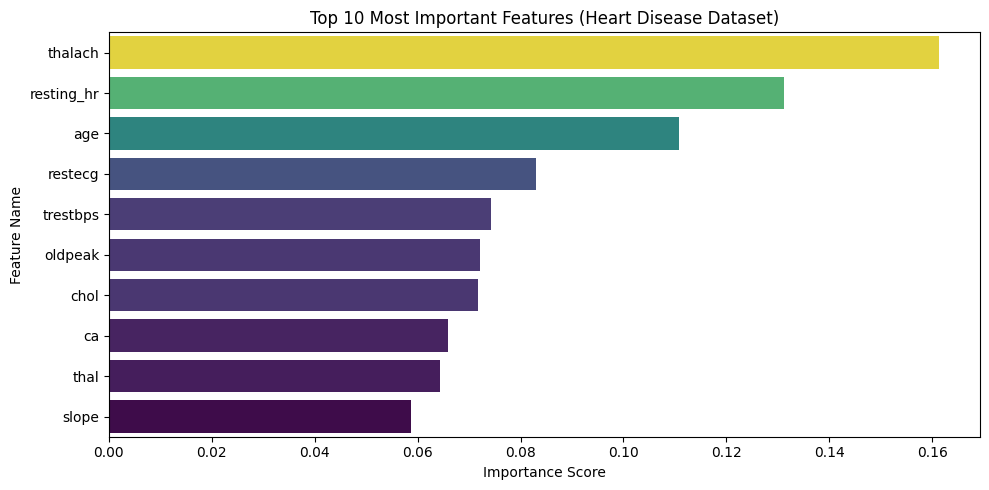

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Create a DataFrame for the importances
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 2. Sort and select the top 10 for better readability
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance_df,
            hue="Importance",
            legend=False,
            palette='viridis')

plt.title('Top 10 Most Important Features (Heart Disease Dataset)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

**Key Concepts Applied**
- `train_test_split:` Prevents "overfitting" by ensuring the model is tested on data it has never seen before.
- $n\_estimators=100$: This tells the model to build 100 individual decision trees and average their results.
- Random State: Setting this to a fixed number (like 42) ensures your results are reproducible every time you run the code.

####**4.1.2 Saving & Loading using joblib and pickle**

Both **pickle** and **joblib** serve the same purpose: **serialization**. This means turning a Python object (your model) into a stream of bytes so it can be saved to a disk and "rehydrated" later.

While **pickle** is the standard Python tool, **joblib** is often preferred in the data science community, specifically for models like **Random Forests**.

**Saving a trained model**

In [26]:
import joblib

joblib.dump(model, "cancer.pkl")


['cancer.pkl']

**Loading the model**

In [27]:
model = joblib.load("cancer.pkl")

After loading, the model behaves exactly like the original trained model and can be used for inference on new patient data.

This separation between training and inference is a core principle in production ML systems.

###**4.2 SHAP Expalanability**

**What Is SHAP?**

**SHAP (SHapley Additive exPlanations)** is a method for explaining machine learning predictions that explains why a machine learning model made a specific prediction.



**It tells you:**

- Which features influenced the prediction

- How much each feature contributed

- Whether each feature pushed the prediction up or down

**It works for:** Classification, Regression, Tree models, Linear models, Even deep learning models



**The Core Idea (Simple Analogy)**

- Imagine a group project.
- The team gets a final score of 90.

**Now you ask:**

- “How much did each member contribute to that 90?”

- SHAP does the same thing for machine learning.

- The final score → model prediction

- The team members → input features

- The contribution → SHAP value

- It fairly distributes the prediction across the features.

**How SHAP Explains a Prediction**

- Every prediction starts from a baseline.

- Baseline = average prediction across all data.

- Then each feature adjusts that baseline.

**Example:**

Baseline risk = 50%

- High tumor radius = +25%

- High texture = +10%

- Low smoothness = +5%
- = Final prediction = 90%

SHAP shows this breakdown clearly.

**What a SHAP Value Means**

Each SHAP value tells you:

- Positive value → pushes prediction higher

- Negative value → pushes prediction lower

- Larger magnitude → stronger impact

So you see both **direction** and **strength**.

**Two Ways SHAP Explains Models**
1. Global Explanation

    - Which features matter most overall?

    - Used to understand the model’s general behavior.

2. Local Explanation

    - Why did the model predict this for this specific patient?

    - This is critical in healthcare.

**Why SHAP Is Important**

Many models are black boxes.They give predictions but no reasoning.

In healthcare, that’s not acceptable.

**SHAP helps:**

- Build trust

- Validate medical logic

- Detect bias

- Explain decisions to clinicians

It turns a black box into something understandable.

**Key takeaway:**

SHAP breaks a prediction into feature contributions so you can see exactly how the model reached its decision.

**Step 1 — Install SHAP**

In [9]:
!pip install shap

**Step 2 — Create SHAP Explainer**

For tree-based models, use `TreeExplainer`.

In [28]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [29]:
shap_values

array([[[-1.60949389e-01,  1.60949389e-01],
        [-2.31869304e-03,  2.31869304e-03],
        [-8.72322203e-04,  8.72322203e-04],
        ...,
        [ 2.79001198e-02, -2.79001198e-02],
        [ 1.57503175e-02, -1.57503175e-02],
        [ 1.80608104e-01, -1.80608104e-01]],

       [[ 2.69309394e-03, -2.69309394e-03],
        [-2.95756751e-03,  2.95756751e-03],
        [-1.73619255e-02,  1.73619255e-02],
        ...,
        [ 1.59335823e-02, -1.59335823e-02],
        [ 5.14107352e-03, -5.14107352e-03],
        [-3.22486016e-02,  3.22486016e-02]],

       [[-6.59442101e-03,  6.59442101e-03],
        [ 7.58665918e-05, -7.58665918e-05],
        [-1.27524529e-02,  1.27524529e-02],
        ...,
        [-1.21679667e-02,  1.21679667e-02],
        [ 3.66436284e-03, -3.66436284e-03],
        [-6.36367282e-02,  6.36367282e-02]],

       ...,

       [[ 6.46670063e-02, -6.46670063e-02],
        [ 2.78678771e-03, -2.78678771e-03],
        [ 6.83397968e-02, -6.83397968e-02],
        ...,
     

**Step 3 — Global Feature Importance (Most Important Step)**

This shows which features matter most across the whole dataset.

In [30]:
shap.summary_plot(
    shap_values[1],   # class 1 (malignant)
    X_test,
    feature_names=X.columns
)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

**What This Plot Shows**

- Features are ranked from most important (top) to least important (bottom)

- Each dot represents one patient

- Red means high feature value

- Blue means low feature value

- Position left/right shows impact on prediction

This is your **global interpretability view**.

**Step 4 — Bar Plot Version (Cleaner for Presentations)**

If you want something simpler and more presentation-friendly:

In [14]:
shap.summary_plot(
    shap_values[1],
    X_test,
    feature_names=feature_names,
    plot_type="bar"
)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

This shows average absolute SHAP values — a clean feature importance ranking.

**Step 5 — Explaining One Individual Prediction (Local Explanation)**

Let’s explain a single patient.

In [ ]:
sample_index = 0

shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][sample_index],
    X_test[sample_index],
    feature_names=feature_names,
    matplotlib=True
)


**This shows:**

- Which features pushed the prediction higher

- Which features pushed it lower

- How the final decision was formed

This is very powerful in healthcare settings.